# Conservación del área según el paso de integración

Se construyen explícitamente `Potential`, `TrajectoryGC` y `SystemGC`. El mismo contorno cuadrado se transporta con tres pasos de integración y se compara el error relativo de su área.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML

from classes import Potential, TrajectoryGC, SystemGC

In [2]:
def square_state(grid, side, points_per_side):
    """Return counter-clockwise GC boundary points in block layout [x, y]."""
    x0 = grid.xmin + grid.period / 2
    y0 = grid.ymin + grid.period / 2
    edge = np.linspace(0.0, side, points_per_side, endpoint=False)

    x = np.concatenate((
        x0 + edge,
        np.full_like(edge, x0 + side),
        x0 + side - edge,
        np.full_like(edge, x0),
    ))
    y = np.concatenate((
        np.full_like(edge, y0),
        y0 + edge,
        np.full_like(edge, y0 + side),
        y0 + side - edge,
    ))
    return np.concatenate((x, y))


def polygon_area(solution, period):
    """Compute the signed area of a periodic GC polygon at every saved time."""
    x, y = np.split(np.asarray(solution.y, dtype=float), 2, axis=0)
    x = x.copy()
    y = y.copy()

    for vertex in range(1, x.shape[0]):
        dx = x[vertex] - x[vertex - 1]
        dy = y[vertex] - y[vertex - 1]
        dx -= period * np.round(dx / period)
        dy -= period * np.round(dy / period)
        x[vertex] = x[vertex - 1] + dx
        y[vertex] = y[vertex - 1] + dy

    return 0.5 * np.sum(
        x * np.roll(y, -1, axis=0) - y * np.roll(x, -1, axis=0),
        axis=0,
    )

In [3]:
potential = Potential.random(
    A=0.7,
    M=25,
    nx=64,
    ny=64,
    seed=27,
    interpolation_order=5,
)
trajectory = TrajectoryGC(rho=0.3)
trajectory.set_initial_state(
    square_state(potential.grid, side=1.0, points_per_side=40)
)
system = SystemGC(potential, trajectory)

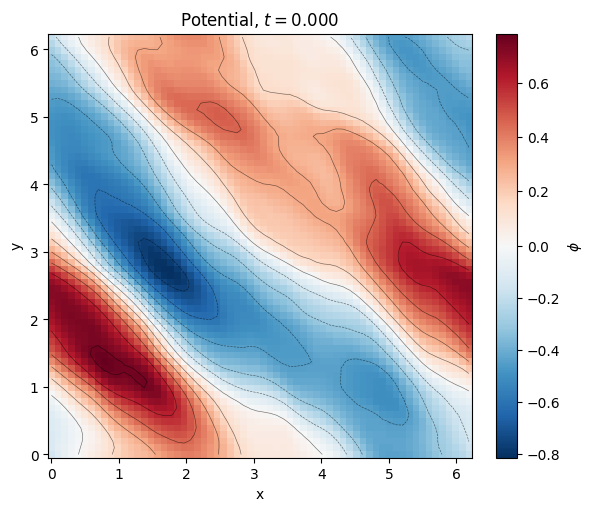

In [4]:
_ = potential.plot()

In [ ]:
steps = (0.01, 0.005, 0.0025)
t_span = (0.0, 6 * np.pi)
n_save_step = 361
solutions = {}
relative_errors = {}

for integration_step in steps:
    solution = system.simulate(
        step=integration_step,
        t_span=t_span,
        n_save_step=n_save_step,
        check_energy=False,
        progress=True,
    )
    area = polygon_area(solution, potential.grid.period)
    relative_error = (area - area[0]) / abs(area[0])
    solutions[integration_step] = solution
    relative_errors[integration_step] = relative_error

print(f"{'step':>10} {'n_steps':>12} {'max |error rel.|':>20} {'error rel. final':>20}")
for integration_step in steps:
    solution = solutions[integration_step]
    error = relative_errors[integration_step]
    print(
        f"{integration_step:10.4g} {solution.n_steps:12d} "
        f"{np.max(np.abs(error)):20.8e} {error[-1]:20.8e}"
    )

SystemGC [==============================] 100.0% (2160/2160, t=18.8496)
SystemGC [==============================] 100.0% (3960/3960, t=18.8496)
SystemGC [=>                            ]   4.0% (300/7560, t=0.747998)

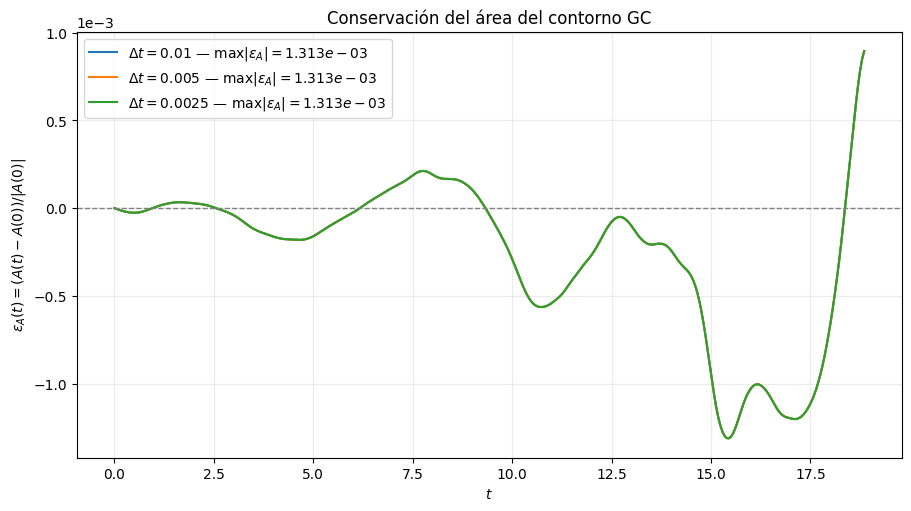

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)

for integration_step in steps:
    solution = solutions[integration_step]
    error = relative_errors[integration_step]
    ax.plot(
        solution.t,
        error,
        label=(
            fr'$\Delta t={integration_step:g}$'
            fr' — $\max|\varepsilon_A|={np.max(np.abs(error)):.3e}$'
        ),
    )

ax.axhline(0.0, color='0.5', ls='--', lw=1)
ax.set(
    xlabel='$t$',
    ylabel=r'$\varepsilon_A(t)=(A(t)-A(0))/|A(0)|$',
    title='Conservación del área del contorno GC',
)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.grid(alpha=0.25)
ax.legend()
plt.show()

In [ ]:
animation = potential.animate(t_max=t_span[1], frames=60)
HTML(animation.to_jshtml())